**PREDICTIVE MODEL FOR AUTOMOBILE SALES**

**OBJECTIVE:**
*To predict automobile sales from the given dataset.
The focus is on data preprocessing, feature engineering, handling missing values, and comparing models such as linear regression and decision tree regression to effectively capture relationships influencing car prices and ensure accurate, explainable predictions for structured automotive datasets.*

**PROBLEM STATEMENT:**
*The problem addressed in this project is the challenge of accurately predicting car prices based on a variety of factors such as manufacturer, model, sales data, vehicle specifications, and market trends. Determining a car's price is complex due to the influence of these multiple features, and manual methods often result in subjective or inaccurate valuations. The project aims to solve this by developing machine learning models that can analyze structured automotive data and produce reliable price predictions for use in car sales and market analysis.*

In [1]:
#CAR SALES PRE-PROCESSING, ALGORITHM SELECTION, PERFORMANCE MEASUREMENT, RESULT ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Car_sales.csv')
df.head()


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [2]:
# This cell previously attempted to use %run with a cell ID.
# Please execute cell a739c6c1 directly to run the K-Fold Cross-Validation for Linear Regression.
# %run a739c6c1 # Removed incorrect command

**TO CHECK THE ROWS AND COLUMNS**

In [3]:
df.shape #To check the shape of the data

(157, 16)

**TO CHECK THE COLUMNS DATA TYPE**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    object 
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    object 
 15  Power_perf_factor    155 non-null    flo

**TO CHECK MEAN,MIN,MAX,COUNT,Q1,Q2,Q3 OF NUMERICAL VALUES**

In [5]:
df.describe()

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


**DATA PRE-PROCESSING**

**APPLYING RIDGE REGRESSION MODEL**

# **DROP AND FILL MISSING VALUES**

In [6]:
# Remove rows with missing 'Price_in_thousands'
modified_dataset = df[df['Price_in_thousands'].notna()].copy() # Use .copy() to avoid SettingWithCopyWarning

print("Original data shape:", df.shape)
print("Shape after removing rows with missing Price_in_thousands:", modified_dataset.shape)

# Identify numerical columns where outliers were detected (based on previous analysis)
outlier_columns = ['Sales_in_thousands', '__year_resale_value', 'Fuel_efficiency', 'Power_perf_factor']

# Apply clipping to the identified columns in modified_dataset
# We will clip values at the 5th and 95th percentiles
import numpy as np
for col in outlier_columns:
    if col in modified_dataset.columns:
        lower_bound = modified_dataset[col].quantile(0.05)
        upper_bound = modified_dataset[col].quantile(0.95)
        modified_dataset[col] = np.clip(modified_dataset[col], lower_bound, upper_bound)

print("\nOutliers clipped in the following columns:", outlier_columns)
display(modified_dataset.head())

Original data shape: (157, 16)
Shape after removing rows with missing Price_in_thousands: (155, 16)

Outliers clipped in the following columns: ['Sales_in_thousands', '__year_resale_value', 'Fuel_efficiency', 'Power_perf_factor']


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
5,Audi,A6,18.780,23.555,Passenger,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,8/9/2011,84.565105


In [7]:
modified_dataset.isnull().sum().sort_values(ascending=False)
#From the modified dataset, we can see that there are missing values in the columns - __year_resale_value, Fuel_efficiency, Curb_weight.


,0
__year_resale_value,36
Fuel_efficiency,2
Curb_weight,1
Manufacturer,0
Vehicle_type,0
Price_in_thousands,0
Model,0
Sales_in_thousands,0
Horsepower,0
Engine_size,0


HANDLING MISSING VALUES _YEAR_RESALE_VALUE

In [8]:
### Replacing the missing values of the column - __year_resale_value in the dataset

print("Total null values in year resale value:",modified_dataset['__year_resale_value'].isnull().sum())
modified_dataset['__year_resale_value']=modified_dataset['__year_resale_value'].fillna(modified_dataset['__year_resale_value'].median())
print("Total Null Value after replacing median value in year_resale_value:",modified_dataset['__year_resale_value'].isnull().sum())

Total null values in year resale value: 36
Total Null Value after replacing median value in year_resale_value: 0


HANDLING MISSING VALUES FUEL_EFFICIENCY

In [9]:
### Replacing the missing values of the column - Fuel_efficiency in the dataset

print("Total null values in Fuel_efficiency:",modified_dataset['Fuel_efficiency'].isnull().sum())
modified_dataset['Fuel_efficiency'] = modified_dataset['Fuel_efficiency'].fillna(modified_dataset['Fuel_efficiency'].median())
print("Total Null Value after replacing median value in Fuel_efficiency:",modified_dataset['Fuel_efficiency'].isnull().sum())

Total null values in Fuel_efficiency: 2
Total Null Value after replacing median value in Fuel_efficiency: 0


**HANDLING OUTLIERS**

In [10]:
from collections import Counter
def detect_outliers(df, n, features_list):
    outlier_indices = []
    for feature in features_list:
        Q1 = np.percentile(df[feature], 25)
        Q3 = np.percentile(df[feature], 75)
        IQR = Q3 - Q1
        outlier_step = 1.5 * IQR
        outlier_list_col = df[(df[feature] < Q1 - outlier_step) | (df[feature] > Q3 + outlier_step)].index
        outlier_indices.extend(outlier_list_col)
    outlier_indices = Counter(outlier_indices)
    multiple_outliers = list(key for key, value in outlier_indices.items() if value > n)
    return multiple_outliers

outliers_to_drop = detect_outliers(modified_dataset, 2, ['Sales_in_thousands', '__year_resale_value', 'Price_in_thousands',
                                               'Fuel_efficiency', 'Power_perf_factor'])
print("We will drop these {} indices: ".format(len(outliers_to_drop)), outliers_to_drop)

We will drop these 0 indices:  []


In [11]:
mean_price_manufacturer = modified_dataset[['Manufacturer', 'Price_in_thousands']].groupby('Manufacturer', as_index = False).mean()
mean_price_manufacturer

,Manufacturer,Price_in_thousands
0,Acura,30.633333
1,Audi,39.980000
2,BMW,33.096667
3,Buick,26.781250
4,Cadillac,40.254000
5,Chevrolet,20.022778
6,Chrysler,23.430833
7,Dodge,24.213636
8,Ford,21.047273
9,Honda,20.277000


In [12]:
modified_dataset.isnull().sum().sort_values(ascending=False)
#From the modified dataset, we can see that there are missing values in the columns - __year_resale_value, Fuel_efficiency, Curb_weight.


,0
Curb_weight,1
Manufacturer,0
Sales_in_thousands,0
Model,0
Vehicle_type,0
Price_in_thousands,0
Engine_size,0
__year_resale_value,0
Horsepower,0
Wheelbase,0


**SEPERATING TWO CLASSES OF MANUFACTURER BASED ON THE MEAN PRICE**

In [13]:
### Seperating the Manufacturers into class 1 and 2

class_1 = []
class_2 = []

for index in range(len(mean_price_manufacturer)):
    if mean_price_manufacturer.iloc[index, 1] <= 30:
        class_1.append(mean_price_manufacturer.iloc[index, 0])
    else:
        class_2.append(mean_price_manufacturer.iloc[index, 0])

print('Manufacturers with less than 30 mean price: ', class_1)
print('Manufacturers with more than 30 mean price: ', class_2)

Manufacturers with less than 30 mean price:  ['Buick', 'Chevrolet', 'Chrysler', 'Dodge', 'Ford', 'Honda', 'Hyundai', 'Infiniti', 'Jeep', 'Mercury', 'Mitsubishi', 'Nissan', 'Oldsmobile', 'Plymouth', 'Pontiac', 'Saab', 'Saturn', 'Subaru', 'Toyota', 'Volkswagen']
Manufacturers with more than 30 mean price:  ['Acura', 'Audi', 'BMW', 'Cadillac', 'Jaguar', 'Lexus', 'Lincoln', 'Mercedes-B', 'Porsche', 'Volvo']


In [14]:
### Modifying the Manufacturer column in the dataset

manufacturer_data = modified_dataset['Manufacturer']
new_manufacturer_data = []

for value in manufacturer_data:
    if value in class_1:
        new_manufacturer_data.append(1)
    else:
        new_manufacturer_data.append(2)

modified_dataset['Manufacturer'] = new_manufacturer_data
modified_dataset

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,2,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,2,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
3,2,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,2,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
5,2,A6,18.780,23.555,Passenger,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,8/9/2011,84.565105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,2,V40,3.545,14.010,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812
153,2,S70,15.245,14.010,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495
154,2,V70,17.531,14.010,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978
155,2,C70,3.493,14.010,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357


**CATEGORICAL TO NUMERICAL AND CREATE NEW COLUMNS BASED ON CATEGORICAL**

In [15]:
modified_dataset = pd.get_dummies(data = modified_dataset, columns = ['Manufacturer', 'Vehicle_type'])
modified_dataset


,Model,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor,Manufacturer_1,Manufacturer_2,Vehicle_type_Car,Vehicle_type_Passenger
0,Integra,16.919,16.360,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150,False,True,False,True
1,TL,39.384,19.875,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778,False,True,False,True
3,RL,8.588,29.725,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779,False,True,False,True
4,A4,20.397,22.255,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639,False,True,False,True
5,A6,18.780,23.555,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,8/9/2011,84.565105,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,V40,3.545,14.010,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812,False,True,False,True
153,S70,15.245,14.010,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495,False,True,False,True
154,V70,17.531,14.010,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978,False,True,False,True
155,C70,3.493,14.010,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357,False,True,False,True


**NORMALIZATION**

In [16]:
### A function to normalize numerical columns

def normalize_columns(dataframe, column):
    data = dataframe[column]
    mini = min(data)
    maxi = max(data)

    new_data = []
    for value in data:
        new_data.append((value - mini)/(maxi - mini))

    dataframe[column] = new_data

numerical_columns = ['Sales_in_thousands', '__year_resale_value','Fuel_efficiency', 'Power_perf_factor','Fuel_capacity','Horsepower']
for each_column in numerical_columns:
    normalize_columns(modified_dataset, each_column)

modified_dataset

,Model,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor,Manufacturer_1,Manufacturer_2,Vehicle_type_Car,Vehicle_type_Passenger
0,Integra,0.081231,0.254694,21.50,1.8,0.215190,101.2,67.3,172.4,2.639,0.133641,0.791667,2/2/2012,0.153081,False,True,False,True
1,TL,0.202493,0.359862,28.40,3.2,0.430380,108.1,70.3,192.9,3.517,0.317972,0.583333,6/3/2011,0.572547,False,True,False,True
3,RL,0.036262,0.654574,42.00,3.5,0.392405,114.6,71.4,196.6,3.850,0.354839,0.375000,3/10/2011,0.572787,False,True,False,True
4,A4,0.100005,0.431072,23.99,1.8,0.240506,102.6,68.2,178.0,2.998,0.281106,0.722222,10/8/2011,0.210092,False,True,False,True
5,A6,0.091276,0.469968,33.95,2.8,0.367089,108.7,76.1,192.0,3.561,0.377880,0.375000,8/9/2011,0.486276,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,V40,0.009040,0.184382,24.40,1.9,0.265823,100.5,67.6,176.6,3.042,0.253456,0.583333,9/21/2011,0.257263,False,True,False,True
153,S70,0.072195,0.184382,27.50,2.4,0.286076,104.9,69.3,185.9,3.208,0.350230,0.583333,11/24/2012,0.309941,False,True,False,True
154,V70,0.084534,0.184382,28.80,2.4,0.286076,104.9,69.3,186.2,3.259,0.350230,0.583333,6/25/2011,0.316298,False,True,False,True
155,C70,0.008760,0.184382,45.50,2.3,0.458228,104.9,71.5,185.7,3.601,0.377880,0.444444,4/26/2011,0.702511,False,True,False,True


**APPLYING LOG TRANSFORMATION AND ROBUST SCALING TO modified_dataset**

In [17]:
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer # Import SimpleImputer for temporary imputation

# Identify numerical columns for transformation and scaling in modified_dataset
numerical_cols = modified_dataset.select_dtypes(include=np.number).columns.tolist()

# Identify skewed features (based on previous analysis or re-check) and the target
# Re-checking skewness to be sure
skewness = modified_dataset[numerical_cols].skew()
skewed_features = skewness[abs(skewness) > 0.5].index.tolist() # Using a threshold of 0.5 for skewness
# Ensure 'Target' is included if it's in numerical_cols, even if its skewness is below threshold after previous steps
if 'Target' in modified_dataset.columns and 'Target' not in skewed_features:
     skewed_features.append('Target')

print("Applying log transformation to skewed features and target in modified_dataset:", skewed_features)

# Apply logarithmic transformation (log1p) to skewed features and the target variable in modified_dataset
for feature in skewed_features:
    if feature in modified_dataset.columns:
        # Add a small constant to avoid log(0) if necessary, although log1p handles 0
        modified_dataset[feature] = np.log1p(modified_dataset[feature])

print("\nSkewness after logarithmic transformation:")
print(modified_dataset[numerical_cols].skew())


# Apply RobustScaler to numerical features in modified_dataset (excluding Target for now, as it's the target)
numerical_features_for_scaling = [col for col in numerical_cols if col != 'Target']

if numerical_features_for_scaling:
    print("\nApplying RobustScaler to numerical features in modified_dataset:", numerical_features_for_scaling)
    robust_scaler = RobustScaler()
    modified_dataset[numerical_features_for_scaling] = robust_scaler.fit_transform(modified_dataset[numerical_features_for_scaling])
else:
    print("\nNo numerical features found for scaling in modified_dataset.")

# **Temporary Imputation after transformations and scaling to handle any remaining NaNs before converting to .values**
# This is a workaround to allow conversion to NumPy arrays. Proper imputation for modeling is in the pipeline.
print("\nApplying temporary imputation after transformations for .values conversion:")
temp_imputer = SimpleImputer(strategy='median')
# Impute all numerical columns, including the target if it has NaNs after transformation
cols_to_temp_impute = modified_dataset.select_dtypes(include=np.number).columns.tolist()
modified_dataset[cols_to_temp_impute] = temp_imputer.fit_transform(modified_dataset[cols_to_temp_impute])


print("\nmodified_dataset after log transformation, Robust Scaling, and temporary imputation:")
display(modified_dataset.head())

# Now redefine X and Y using the modified_dataset with transformations, scaling, and temporary imputation
# Assuming 'Target' is already created and is the target variable
if 'Target' in modified_dataset.columns:
    X = modified_dataset.drop('Target', axis=1).values
    Y = modified_dataset['Target'].values
    print("\nSuccessfully updated X and Y after transformations and scaling from modified_dataset.")
else:
    print("\n'Target' column not found in modified_dataset. Please ensure it is created before this step.")

Applying log transformation to skewed features and target in modified_dataset: ['Sales_in_thousands', '__year_resale_value', 'Price_in_thousands', 'Engine_size', 'Horsepower', 'Wheelbase', 'Curb_weight', 'Fuel_capacity', 'Power_perf_factor']

Skewness after logarithmic transformation:
Sales_in_thousands     1.188122
__year_resale_value    1.500199
Price_in_thousands     0.507305
Engine_size            0.310463
Horsepower             0.566906
Wheelbase              0.604640
Width                  0.479370
Length                -0.052424
Curb_weight            0.185232
Fuel_capacity          0.648705
Fuel_efficiency       -0.026394
Power_perf_factor      0.240691
dtype: float64

Applying RobustScaler to numerical features in modified_dataset: ['Sales_in_thousands', '__year_resale_value', 'Price_in_thousands', 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor']

Applying temporary imputation after transformat

,Model,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor,Manufacturer_1,Manufacturer_2,Vehicle_type_Car,Vehicle_type_Passenger
0,Integra,-0.250559,0.442815,-0.102130,-1.041617,-0.555897,-0.651205,-0.633663,-0.827957,-0.917640,-1.138174,0.8,2/2/2012,-0.518987,False,True,False,True
1,TL,0.188363,1.060863,0.384570,0.142485,0.731858,0.119550,-0.039604,0.274194,0.206751,0.000000,0.2,6/3/2011,0.624812,False,True,False,True
3,RL,-0.425969,2.567052,1.076383,0.343968,0.519332,0.802271,0.178218,0.473118,0.576785,0.208415,-0.4,3/10/2011,0.625377,False,True,False,True
4,A4,-0.179478,1.452768,0.088854,-1.041617,-0.393037,-0.490695,-0.455446,-0.526882,-0.428192,-0.214328,0.6,10/8/2011,-0.341074,False,True,False,True
5,A6,-0.212373,1.658677,0.699218,-0.149795,0.374402,0.184252,1.108911,0.225806,0.257180,0.335814,-0.4,8/9/2011,0.416805,False,True,False,True



'Target' column not found in modified_dataset. Please ensure it is created before this step.


**Spliting datataset - Train & Test**

In [18]:
### Prepare the dataset for modeling
import numpy as np
import pandas as pd

# Create the 'Target' column if 'Price_in_thousands' exists and 'Target' does not
if 'Price_in_thousands' in modified_dataset.columns and 'Target' not in modified_dataset.columns:
    modified_dataset['Target'] = modified_dataset['Price_in_thousands']
    # Drop 'Price_in_thousands' after creating 'Target'
    modified_dataset.drop('Price_in_thousands', axis=1, inplace=True)
elif 'Price_in_thousands' in modified_dataset.columns:
     # If 'Price_in_thousands' exists but 'Target' does, just drop 'Price_in_thousands'
     modified_dataset.drop('Price_in_thousands', axis=1, inplace=True)


# Drop the 'Model' and 'Latest_Launch' columns if they exist
columns_to_drop = ['Model', 'Latest_Launch']
for col in columns_to_drop:
    if col in modified_dataset.columns:
        modified_dataset.drop(col, axis=1, inplace=True)

# Define features (X) and target (Y)
# X includes all columns except 'Target'
X = modified_dataset.drop('Target', axis=1).values
# Y is the 'Target' column
Y = modified_dataset['Target'].values

modified_dataset.head()

,Sales_in_thousands,__year_resale_value,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor,Manufacturer_1,Manufacturer_2,Vehicle_type_Car,Vehicle_type_Passenger,Target
0,-0.250559,0.442815,-1.041617,-0.555897,-0.651205,-0.633663,-0.827957,-0.917640,-1.138174,0.8,-0.518987,False,True,False,True,-0.102130
1,0.188363,1.060863,0.142485,0.731858,0.119550,-0.039604,0.274194,0.206751,0.000000,0.2,0.624812,False,True,False,True,0.384570
3,-0.425969,2.567052,0.343968,0.519332,0.802271,0.178218,0.473118,0.576785,0.208415,-0.4,0.625377,False,True,False,True,1.076383
4,-0.179478,1.452768,-1.041617,-0.393037,-0.490695,-0.455446,-0.526882,-0.428192,-0.214328,0.6,-0.341074,False,True,False,True,0.088854
5,-0.212373,1.658677,-0.149795,0.374402,0.184252,1.108911,0.225806,0.257180,0.335814,-0.4,0.416805,False,True,False,True,0.699218


**TRAINING AND TESTING A DATASET**

In [19]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor  # Changed from DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score  # Using regression metrics
import numpy as np

# Initialize KFold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=27)

# Store performance metrics for each fold
fold_rmse = []
fold_r2 = []

# Loop through each fold
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]

    # Check the size of the test set
    print(f"Test set size: {X_test.shape[0]}")

    # Initialize and train Random Forest Regressor model
    model = RandomForestRegressor(random_state=27)  # Changed from DecisionTreeRegressor
    model.fit(X_train, Y_train)

    # Predict and evaluate
    Y_pred = model.predict(X_test)

    # Calculate regression metrics
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2 = r2_score(Y_test, Y_pred)

    fold_rmse.append(rmse)
    fold_r2.append(r2)

# Print results
print("RMSE scores for each fold:", fold_rmse)
print("Mean RMSE:", np.mean(fold_rmse))
print("Standard deviation of RMSE:", np.std(fold_rmse))

print("\nR-squared scores for each fold:", fold_r2)
print("Mean R-squared:", np.mean(fold_r2))
print("Standard deviation of R-squared:", np.std(fold_r2))

Test set size: 31
Test set size: 31
Test set size: 31
Test set size: 31
Test set size: 31
RMSE scores for each fold: [np.float64(0.2711890537090952), np.float64(0.22241501999011884), np.float64(0.17969912970483332), np.float64(0.22259806655571945), np.float64(0.2748907382539359)]
Mean RMSE: 0.23415840164274054
Standard deviation of RMSE: 0.035405516796785816

R-squared scores for each fold: [0.863480509147011, 0.9127227246760798, 0.9338906220466043, 0.9201135881546968, 0.917841155412454]
Mean R-squared: 0.9096097198873692
Standard deviation of R-squared: 0.024104957462689126


In [20]:
X

array([[-0.2505587327858675, 0.4428154990088252, -1.0416172558166095,
        ..., True, False, True],
       [0.18836267761629563, 1.0608626503772565, 0.14248457251243168,
        ..., True, False, True],
       [-0.4259693514527815, 2.567051503134535, 0.343968211019685, ...,
        True, False, True],
       ...,
       [-0.23796206458561758, 0.0, -0.4746128771826591, ..., True, False,
        True],
       [-0.5370370764369506, 0.0, -0.561794110634557, ..., True, False,
        True],
       [-0.20851436563526649, 0.0, -0.07393697293302975, ..., True,
        False, True]], dtype=object)

In [21]:
from collections import OrderedDict
### Dictionary to store model and its rmse

model_rmse = OrderedDict()

### Dictionary to store model and its r-squared

model_r2 = OrderedDict()

**APPLYING K-FOLD CROSS-VALIDATION WITH LINEAR REGRESSION**

In [22]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer # Import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize KFold with 5 splits
kf_lr = KFold(n_splits=5, shuffle=True, random_state=27)

# Store performance metrics for each fold
fold_rmse_lr = []
fold_r2_lr = []

# Create an imputer to fill missing values with the median
imputer_lr = SimpleImputer(strategy='median')


# Loop through each fold
for train_index, test_index in kf_lr.split(X):
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    Y_train_fold, Y_test_fold = Y[train_index], Y[test_index]

    # Impute missing values within the fold
    X_train_fold_imputed = imputer_lr.fit_transform(X_train_fold)
    X_test_fold_imputed = imputer_lr.transform(X_test_fold)


    # Initialize and train Linear Regression model
    model_lr = LinearRegression()
    model_lr.fit(X_train_fold_imputed, Y_train_fold)

    # Predict and evaluate
    Y_pred_fold = model_lr.predict(X_test_fold_imputed)

    # Calculate regression metrics
    rmse_fold = np.sqrt(mean_squared_error(Y_test_fold, Y_pred_fold))
    r2_fold = r2_score(Y_test_fold, Y_pred_fold)

    fold_rmse_lr.append(rmse_fold)
    fold_r2_lr.append(r2_fold)

# Print results
print("RMSE scores for each fold (Linear Regression):", fold_rmse_lr)
print("Mean RMSE (Linear Regression):", np.mean(fold_rmse_lr))
print("Standard deviation of RMSE (Linear Regression):", np.std(fold_rmse_lr))

print("\nR-squared scores for each fold (Linear Regression):", fold_r2_lr)
print("Mean R-squared (Linear Regression):", np.mean(fold_r2_lr))
print("Standard deviation of R-squared (Linear Regression):", np.std(fold_r2_lr))

# Add the mean cross-validation results to the comparison dictionaries
model_rmse['Linear Regression (KFold)'] = np.mean(fold_rmse_lr)
model_r2['Linear Regression (KFold)'] = np.mean(fold_r2_lr)

RMSE scores for each fold (Linear Regression): [np.float64(0.3096754460365402), np.float64(0.16203183522369366), np.float64(0.2253449144682742), np.float64(0.23775132323909984), np.float64(0.41028521540002727)]
Mean RMSE (Linear Regression): 0.26901774687352703
Standard deviation of RMSE (Linear Regression): 0.08478258900723254

R-squared scores for each fold (Linear Regression): [0.8219820103788411, 0.9536794553946251, 0.8960399101741007, 0.9088669249197558, 0.8169769270945506]
Mean R-squared (Linear Regression): 0.8795090455923746
Standard deviation of R-squared (Linear Regression): 0.05264224515907208


**APPLYING K-FOLD CROSS-VALIDATION WITH DECISION TREE REGRESSION**

In [23]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize KFold with 5 splits (using the same random state as before)
kf_dt = KFold(n_splits=5, shuffle=True, random_state=27) # Using a specific random state for reproducibility

# Store performance metrics for each fold
fold_rmse_dt = []
fold_r2_dt = []

# Loop through each fold
# Assuming X and Y are defined from previous data preprocessing steps
for train_index, test_index in kf_dt.split(X):
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    Y_train_fold, Y_test_fold = Y[train_index], Y[test_index]

    # Initialize and train Decision Tree Regressor model for the current fold
    decision_tree_regressor_fold = DecisionTreeRegressor(random_state=27) # Using a specific random state for reproducibility
    decision_tree_regressor_fold.fit(X_train_fold, Y_train_fold)

    # Predict and evaluate on the test fold
    Y_pred_fold = decision_tree_regressor_fold.predict(X_test_fold)

    # Calculate regression metrics
    rmse_fold = np.sqrt(mean_squared_error(Y_test_fold, Y_pred_fold))
    r2_fold = r2_score(Y_test_fold, Y_pred_fold)

    fold_rmse_dt.append(rmse_fold)
    fold_r2_dt.append(r2_fold)

# Print results
print("RMSE scores for each fold (Decision Tree Regression):", fold_rmse_dt)
print("Mean RMSE (Decision Tree Regression):", np.mean(fold_rmse_dt))
print("Standard deviation of RMSE (Decision Tree Regression):", np.std(fold_rmse_dt))

print("\nR-squared scores for each fold (Decision Tree Regression):", fold_r2_dt)
print("Mean R-squared (Decision Tree Regression):", np.mean(fold_r2_dt))
print("Standard deviation of R-squared (Decision Tree Regression):", np.std(fold_r2_dt))

# Add the mean cross-validation results to the comparison dictionaries
model_rmse['Decision Tree Regression (KFold)'] = np.mean(fold_rmse_dt)
model_r2['Decision Tree Regression (KFold)'] = np.mean(fold_r2_dt)

RMSE scores for each fold (Decision Tree Regression): [np.float64(0.3113335561332093), np.float64(0.34849622046352463), np.float64(0.29172949266742654), np.float64(0.37511779512968324), np.float64(0.3294122636926265)]
Mean RMSE (Decision Tree Regression): 0.33121786561729405
Standard deviation of RMSE (Decision Tree Regression): 0.028926537703576116

R-squared scores for each fold (Decision Tree Regression): [0.820070566249931, 0.7857261861083631, 0.8257664455003768, 0.7731360583854436, 0.8820185756975011]
Mean R-squared (Decision Tree Regression): 0.8173435663883231
Standard deviation of R-squared (Decision Tree Regression): 0.03798736829398951


In [24]:
### Tabulating the results
from tabulate import tabulate
table = []
table.append(['S.No.', 'Regression Model', 'Root Mean Squared Error', 'R-squared'])
count = 1

# Add Random Forest Regressor results from the KFold evaluation
# Using the mean RMSE and R2 from the folds as the overall performance metric
if 'fold_rmse' in locals() and 'fold_r2' in locals():
    model_rmse['Random Forest Regression (KFold)'] = np.mean(fold_rmse)
    model_r2['Random Forest Regression (KFold)'] = np.mean(fold_r2)

# Add Decision Tree Regressor results from the KFold evaluation
if 'fold_rmse_dt' in locals() and 'fold_r2_dt' in locals():
    model_rmse['Decision Tree Regression (KFold)'] = np.mean(fold_rmse_dt)
    model_r2['Decision Tree Regression (KFold)'] = np.mean(fold_r2_dt)


# Remove specific entries if they exist to avoid confusion with KFold results
if 'Multi Linear Regression' in model_rmse:
    del model_rmse['Multi Linear Regression']
if 'Multi Linear Regression' in model_r2:
    del model_r2['Multi Linear Regression']

if 'Decision Tree Regression' in model_rmse:
     del model_rmse['Decision Tree Regression']
if 'Decision Tree Regression' in model_r2:
     del model_r2['Decision Tree Regression']


# Sort models by RMSE for better comparison
sorted_models = sorted(model_rmse.items(), key=lambda item: item[1])

for model_name, rmse_value in sorted_models:
    row = [count, model_name, rmse_value, model_r2[model_name]]
    table.append(row)
    count += 1

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═════════╤══════════════════════════════════╤═══════════════════════════╤═════════════╕
│   S.No. │ Regression Model                 │   Root Mean Squared Error │   R-squared │
╞═════════╪══════════════════════════════════╪═══════════════════════════╪═════════════╡
│       1 │ Random Forest Regression (KFold) │                  0.234158 │    0.90961  │
├─────────┼──────────────────────────────────┼───────────────────────────┼─────────────┤
│       2 │ Linear Regression (KFold)        │                  0.269018 │    0.879509 │
├─────────┼──────────────────────────────────┼───────────────────────────┼─────────────┤
│       3 │ Decision Tree Regression (KFold) │                  0.331218 │    0.817344 │
╘═════════╧══════════════════════════════════╧═══════════════════════════╧═════════════╛


**VISUALIZING MODEL PERFORMANCE METRICS**

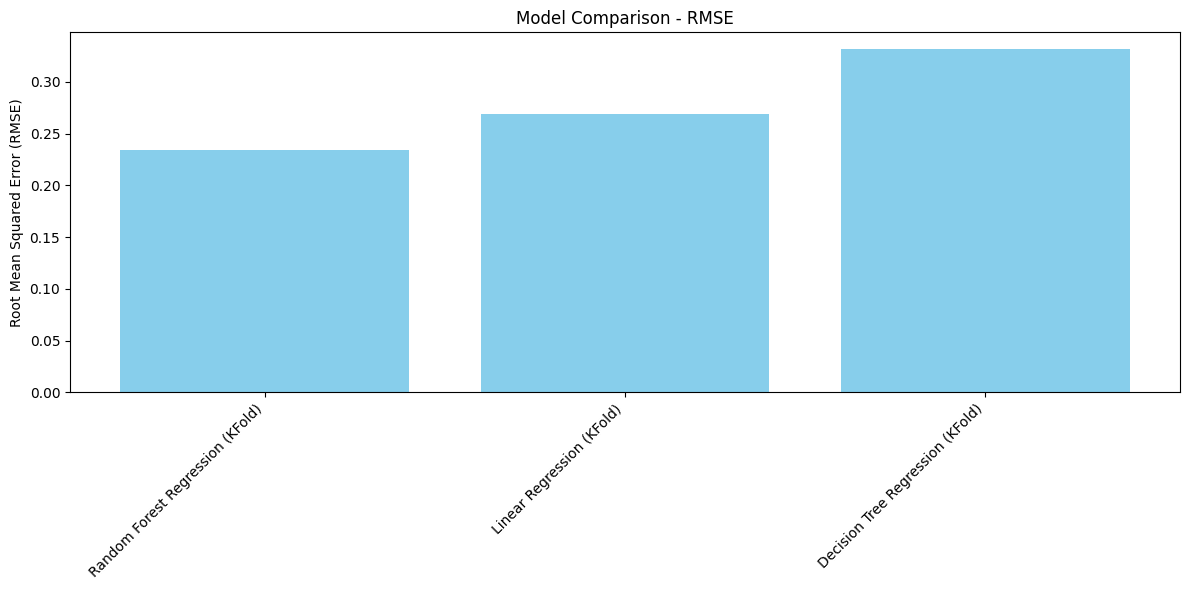

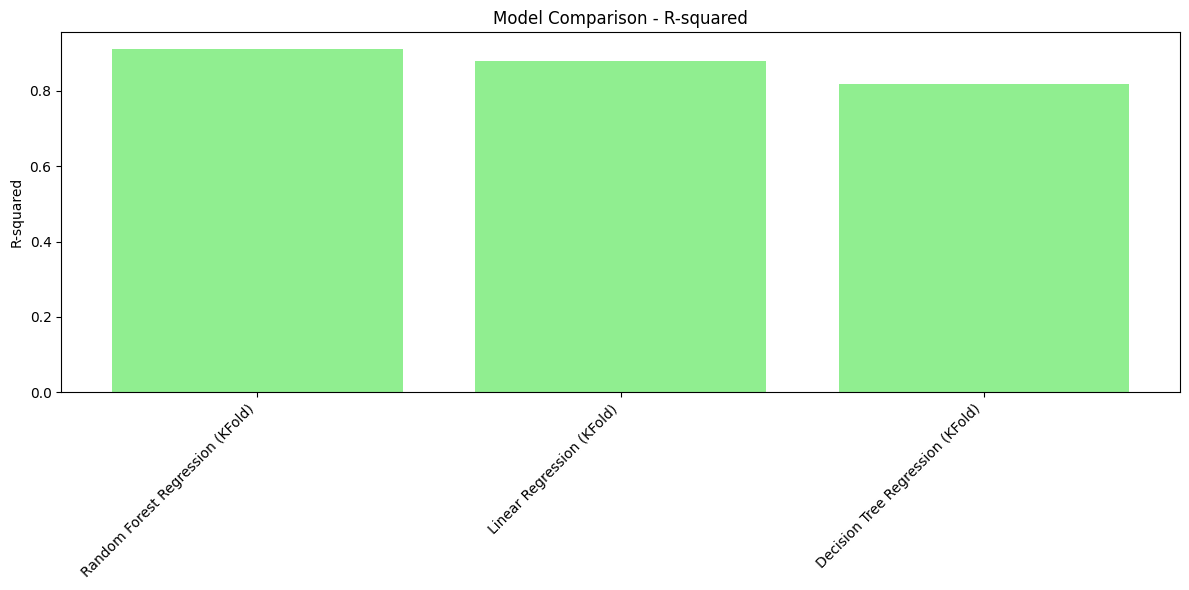

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame from the model performance dictionaries
performance_df = pd.DataFrame({
    'Model': list(model_rmse.keys()),
    'RMSE': list(model_rmse.values()),
    'R-squared': list(model_r2.values())
})

# Sort the DataFrame by RMSE for better visualization
performance_df = performance_df.sort_values(by='RMSE')

# Plotting RMSE
plt.figure(figsize=(12, 6))
plt.bar(performance_df['Model'], performance_df['RMSE'], color='skyblue')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Model Comparison - RMSE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting R-squared
plt.figure(figsize=(12, 6))
plt.bar(performance_df['Model'], performance_df['R-squared'], color='lightgreen')
plt.ylabel('R-squared')
plt.title('Model Comparison - R-squared')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**VISUALIZING MODEL PERFORMANCE METRICS WITH A SPIDER PLOT**

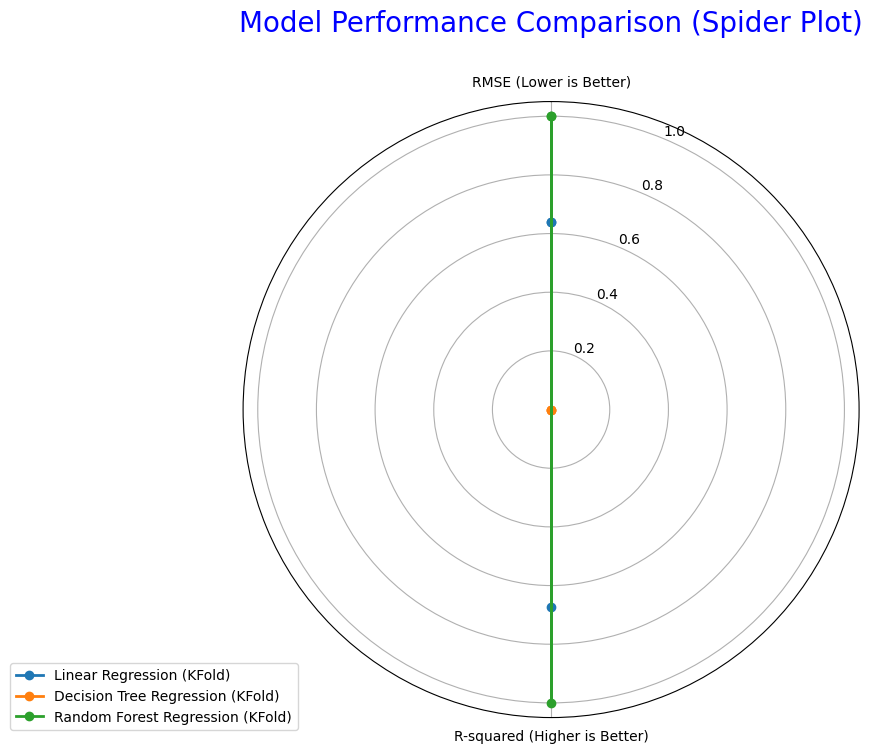

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create a DataFrame from the model performance dictionaries
performance_df = pd.DataFrame({
    'Model': list(model_rmse.keys()),
    'RMSE': list(model_rmse.values()),
    'R-squared': list(model_r2.values())
})

# Handle potential None values in R-squared (e.g., if some models weren't evaluated for R2)
performance_df['R-squared'] = performance_df['R-squared'].fillna(0) # Replace NaN R2 with 0 for plotting


# Normalize the metrics for the spider plot
# For RMSE, lower is better, so normalize such that 0 is the min RMSE and 1 is the max RMSE
# Then subtract from 1 so that higher values on the plot represent better performance (lower RMSE)
min_rmse = performance_df['RMSE'].min()
max_rmse = performance_df['RMSE'].max()
performance_df['RMSE_normalized'] = 1 - (performance_df['RMSE'] - min_rmse) / (max_rmse - min_rmse)

# For R-squared, higher is better, so normalize such that 0 is the min R2 and 1 is the max R2
min_r2 = performance_df['R-squared'].min()
max_r2 = performance_df['R-squared'].max()
# Handle case where all R2 values are the same or min_r2 == max_r2
if max_r2 - min_r2 == 0:
    performance_df['R2_normalized'] = 0.5 # Assign a middle value if all are the same
else:
    performance_df['R2_normalized'] = (performance_df['R-squared'] - min_r2) / (max_r2 - min_r2)


# Prepare data for the spider plot
labels = np.array(['RMSE (Lower is Better)', 'R-squared (Higher is Better)'])
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Complete the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot data for each model
for index, row in performance_df.iterrows():
    values = np.array([row['RMSE_normalized'], row['R2_normalized']]).tolist()
    values += values[:1] # Complete the loop
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'])
    ax.fill(angles, values, alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.grid(True)

plt.title('Model Performance Comparison (Spider Plot)', size=20, color='blue', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()

**TRAINING RANDOM FOREST REGRESSOR ON FULL DATASET FOR GRADIO**

In [27]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# Assuming X and Y are defined from the latest preprocessing steps (e.g., after outlier handling, imputation, scaling, log transform)

# Train the Random Forest Regressor model on the entire dataset
# Using the same random state as before for reproducibility
random_forest_regressor_final = RandomForestRegressor(random_state=27)
random_forest_regressor_final.fit(X, Y)

print("Random Forest Regressor trained on the full dataset.")

Random Forest Regressor trained on the full dataset.


**CREATING GRADIO INTERFACE**

In [29]:
import gradio as gr
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor

# Assuming random_forest_regressor_final is trained (from cell 4de417b7)
# Assuming modified_dataset is available (from previous preprocessing steps)
# Assuming class_1 and class_2 lists for manufacturer classification are available (from cell lYC1or74BHxi)

# Get feature names from the modified_dataset before converting to NumPy array X
# Assuming modified_dataset is available and reflects the final features used in X
# Drop the target column to get feature names
final_feature_names = modified_dataset.drop('Target', axis=1).columns.tolist()

# Identify numerical and categorical columns for preprocessing
numerical_cols_for_preprocessing = modified_dataset.drop('Target', axis=1).select_dtypes(include=np.number).columns.tolist()
categorical_cols_encoded = [col for col in final_feature_names if col.startswith('Manufacturer_') or col.startswith('Vehicle_type_')]

# Define skewed features that need log transformation (based on analysis in cell 6d578267)
# Exclude the target column ('Price_in_thousands'/'Target')
skewed_features_for_log = ['Sales_in_thousands', '__year_resale_value', 'Engine_size',
                           'Horsepower', 'Wheelbase', 'Curb_weight', 'Fuel_capacity',
                           'Power_perf_factor']
# Filter to include only features present in the final_feature_names
skewed_features_for_log = [feature for feature in skewed_features_for_log if feature in final_feature_names]


# Define the numerical preprocessor pipeline (imputation and scaling)
preprocessor_numerical = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())])

# Fit the numerical preprocessor on the numerical columns of the training data (X)
# Assuming X is the full preprocessed training data (from cell 6d578267 or HqFnfe3d87F-)
# We need the numerical columns of the training data X
if isinstance(X, np.ndarray):
     X_df_full = pd.DataFrame(X, columns=final_feature_names)
else:
     X_df_full = X

preprocessor_numerical.fit(X_df_full[numerical_cols_for_preprocessing])


# Define a class to encapsulate the model and preprocessing logic
class CarPricePredictor:
    def __init__(self, model, numerical_preprocessor, final_feature_names,
                 numerical_cols, categorical_cols, skewed_features, class_1, class_2):
        self.model = model
        self.numerical_preprocessor = numerical_preprocessor
        self.final_feature_names = final_feature_names
        self.numerical_cols = numerical_cols
        self.categorical_cols = categorical_cols
        self.skewed_features = skewed_features
        self.class_1 = class_1
        self.class_2 = class_2
        # Approximate exchange rate
        self.usd_to_inr_rate = 83

    def predict_price(self, manufacturer_name, vehicle_type, sales_in_thousands, year_resale_value,
                      engine_size, horsepower, wheelbase, width,
                      length, curb_weight, fuel_capacity, fuel_efficiency,
                      power_perf_factor):
        """
        Predicts car price using the trained Random Forest Regressor model.
        Accepts original feature inputs and performs necessary preprocessing.
        """
        # Map original manufacturer name to one-hot encoded columns (Manufacturer_1, Manufacturer_2)
        manufacturer_1 = manufacturer_name in self.class_1
        manufacturer_2 = manufacturer_name in self.class_2

        # Map original vehicle type to one-hot encoded columns (Vehicle_type_Car, Vehicle_type_Passenger)
        vehicle_type_car = vehicle_type == 'Car'
        vehicle_type_passenger = vehicle_type == 'Passenger'

        # Create a dictionary with input features matching the FINAL feature names used for training
        input_dict = {
            'Sales_in_thousands': sales_in_thousands,
            '__year_resale_value': year_resale_value,
            'Engine_size': engine_size,
            'Horsepower': horsepower,
            'Wheelbase': wheelbase,
            'Width': width,
            'Length': length,
            'Curb_weight': curb_weight,
            'Fuel_capacity': fuel_capacity,
            'Fuel_efficiency': fuel_efficiency,
            'Power_perf_factor': power_perf_factor,
            'Manufacturer_1': manufacturer_1,
            'Manufacturer_2': manufacturer_2,
            'Vehicle_type_Car': vehicle_type_car,
            'Vehicle_type_Passenger': vehicle_type_passenger
        }

        # Create a pandas DataFrame from the input dictionary
        # Ensure the order of columns matches final_feature_names
        input_data = pd.DataFrame([input_dict]).reindex(columns=self.final_feature_names, fill_value=False)

        # Separate numerical and categorical parts of the input data
        input_numerical = input_data[self.numerical_cols]
        input_categorical = input_data[self.categorical_cols]

        # Apply the numerical preprocessor (imputation and scaling)
        input_numerical_processed_array = self.numerical_preprocessor.transform(input_numerical)

        # Convert processed numerical array back to DataFrame for easier manipulation
        input_numerical_processed_df = pd.DataFrame(input_numerical_processed_array, columns=self.numerical_cols)

        # Apply logarithmic transformation (log1p) to skewed features in the processed numerical DataFrame
        for feature in self.skewed_features:
             if feature in input_numerical_processed_df.columns:
                 input_numerical_processed_df[feature] = input_numerical_processed_df[feature].replace([np.inf, -np.inf], np.nan)
                 temp_imputer_log = SimpleImputer(strategy='median')
                 if input_numerical_processed_df[feature].isnull().any():
                      input_numerical_processed_df[feature] = temp_imputer_log.fit_transform(input_numerical_processed_df[[feature]])[:, 0]
                 input_numerical_processed_df[feature] = np.log1p(input_numerical_processed_df[feature])

        # Combine the processed numerical features with the original categorical (boolean) features
        processed_input_df_combined = pd.concat([input_numerical_processed_df, input_categorical.reset_index(drop=True)], axis=1)

        # Reorder columns to match the order in final_feature_names
        processed_input_df_combined = processed_input_df_combined.reindex(columns=self.final_feature_names)

        # Convert the final processed DataFrame to a NumPy array for the model
        final_processed_input = processed_input_df_combined.values

        # Make prediction using the trained model
        prediction_transformed = self.model.predict(final_processed_input)

        # Inverse transform the prediction
        prediction_original_scale = np.expm1(prediction_transformed)

        # Convert price from thousands USD to total USD, then to INR
        price_in_usd = prediction_original_scale[0] * 1000
        price_in_inr = price_in_usd * self.usd_to_inr_rate

        return f"₹{price_in_inr:,.2f}"


# Create an instance of the predictor class
predictor = CarPricePredictor(model=random_forest_regressor_final,
                              numerical_preprocessor=preprocessor_numerical,
                              final_feature_names=final_feature_names,
                              numerical_cols=numerical_cols_for_preprocessing,
                              categorical_cols=categorical_cols_encoded,
                              skewed_features=skewed_features_for_log,
                              class_1=class_1,
                              class_2=class_2)


# Create Gradio input components based on the desired user input
input_components_gradio = [
    gr.Dropdown(label="Manufacturer", choices=class_1 + class_2), # Use combined list of original manufacturers
    gr.Dropdown(label="Vehicle Type", choices=['Car', 'Passenger']), # Use original vehicle types
    gr.Number(label="Sales in thousands"),
    gr.Number(label="__year_resale_value"),
    gr.Number(label="Engine Size"),
    gr.Number(label="Horsepower"),
    gr.Number(label="Wheelbase"),
    gr.Number(label="Width"),
    gr.Number(label="Length"),
    gr.Number(label="Curb Weight"),
    gr.Number(label="Fuel Capacity"),
    gr.Number(label="Fuel Efficiency"),
    gr.Number(label="Power perf factor")
]

# Create the Gradio interface, passing the predict_price method of the class instance
iface = gr.Interface(
    fn=predictor.predict_price, # Pass the method here
    inputs=input_components_gradio,
    outputs=gr.Text(label="Predicted Price (INR)"),
    title="Automobile Price Predictor (Random Forest)",
    description="Enter the features of a car to predict its price."
)

# Launch the interface
iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://fdaf1f4ca6a25111ed.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://fdaf1f4ca6a25111ed.gradio.live
